# HW03-ICA :: Part B (Transfer Learning + Fine-Tuning with ResNet50)

Adam Nelson-Archer, PSID: 2140122

## Goal

Use transfer learning with a pre-trained ResNet50 (ImageNet weights) to classify horses vs. camels.

Required steps for Part B:
1. Load the pre-trained base model and weights.
2. Train the model using weight fine-tuning.
3. Evaluate performance and report the confusion matrix.
4. State which layers were kept/replaced, and report the best architecture you found (based on your run).

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Reproducibility (best-effort)
SEED = 6373
np.random.seed(SEED)

try:
    import tensorflow as tf
except Exception as e:
    print("TensorFlow import failed:")
    print(type(e).__name__, str(e))
    print(
        "\nCommon fix (NumPy/TensorFlow mismatch):\n"
        "- In the same environment as this notebook, run:\n"
        "  pip install \"numpy<2\" --force-reinstall\n\n"
        "Then restart the kernel and re-run this cell."
    )
    raise

tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("GPU available:", bool(tf.config.list_physical_devices("GPU")))
print("CWD:", os.getcwd())

TensorFlow: 2.16.2
NumPy: 1.26.4
GPU available: False
CWD: c:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW3\Part_B


In [4]:
# Paths (relative to this notebook: HW3/Part_B)
NOTEBOOK_DIR = Path.cwd()
DATASET_DIR = (NOTEBOOK_DIR / ".." / "dataset").resolve()
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

# ResNet50 default input size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("DATASET_DIR =", DATASET_DIR)
print("TRAIN_DIR   =", TRAIN_DIR)
print("TEST_DIR    =", TEST_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Test exists:", TEST_DIR.exists())

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(
        "Dataset folders not found. Expected:\n"
        f"- {TRAIN_DIR}\n"
        f"- {TEST_DIR}\n\n"
        "Create these folders and place class subfolders inside them, e.g.:\n"
        "- HW3/dataset/train/horses\n"
        "- HW3/dataset/train/camels\n"
        "- HW3/dataset/test/horses\n"
        "- HW3/dataset/test/camels\n"
    )

DATASET_DIR = C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW3\dataset
TRAIN_DIR   = C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW3\dataset\train
TEST_DIR    = C:\Users\PC\Desktop\projects_and_code\School\COSC6373\HW3\dataset\test
Train exists: True
Test exists: True


In [5]:
# Load datasets
# We'll create a validation split from TRAIN_DIR for model selection.
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="binary",
    shuffle=False,  # important for confusion matrix alignment
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print("Class names (alphabetical):", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 360 files belonging to 2 classes.
Using 288 files for training.
Found 360 files belonging to 2 classes.
Using 72 files for validation.
Found 40 files belonging to 2 classes.
Class names (alphabetical): ['camel', 'horse']


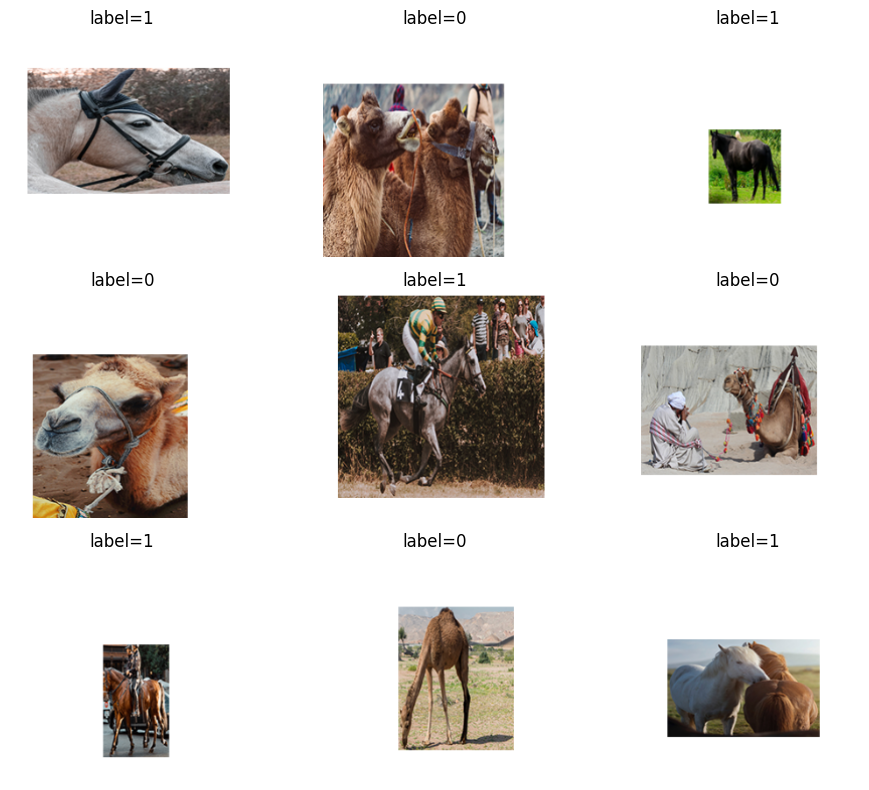

In [6]:
# Visualize a few training images
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"label={int(labels[i].numpy()[0])}")
        plt.axis("off")
plt.tight_layout()

In [7]:
# Build transfer-learning model (ResNet50 base + new classification head)
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input


data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
)

# Freeze the base model for initial training of the new head
base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs, name="resnet50_horses_vs_camels")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "resnet50_horses_vs_camels"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5913 - auc: 0.6147 - loss: 0.6928 - val_accuracy: 0.6806 - val_auc: 0.8466 - val_loss: 0.5133
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.7640 - auc: 0.8658 - loss: 0.4878 - val_accuracy: 0.8333 - val_auc: 0.9599 - val_loss: 0.3957
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8236 - auc: 0.9253 - loss: 0.3945 - val_accuracy: 0.9444 - val_auc: 0.9772 - val_loss: 0.2892
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9141 - auc: 0.9690 - loss: 0.2896 - val_accuracy: 0.9028 - val_auc: 0.9835 - val_loss: 0.2605
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.9158 - auc: 0.9754 - loss: 0.2501 - val_accuracy: 0.9028 - val_auc: 0.9894 - val_loss: 0.2258


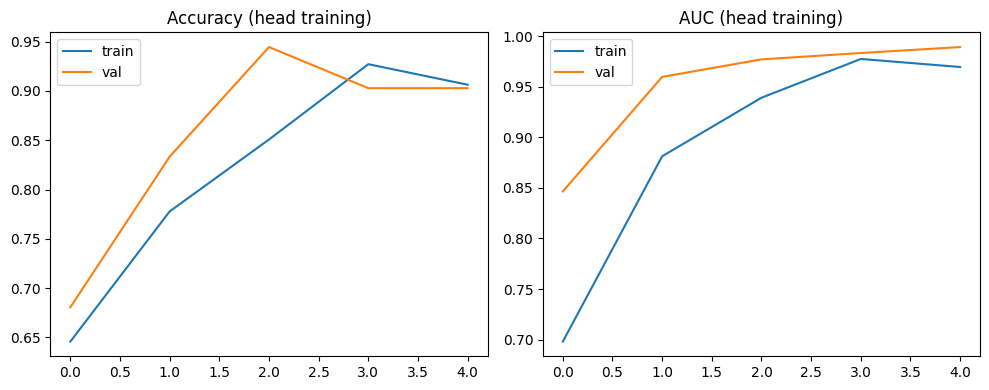

In [8]:
# Train the new classification head
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=3, restore_best_weights=True
    )
]

INITIAL_EPOCHS = 5
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_head.history.get("accuracy", []), label="train")
plt.plot(history_head.history.get("val_accuracy", []), label="val")
plt.title("Accuracy (head training)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_head.history.get("auc", []), label="train")
plt.plot(history_head.history.get("val_auc", []), label="val")
plt.title("AUC (head training)")
plt.legend()
plt.tight_layout()

Base model trainable layers: 21 / 175
Epoch 1/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.9349 - auc: 0.9839 - loss: 0.2196 - val_accuracy: 0.9167 - val_auc: 0.9913 - val_loss: 0.1736
Epoch 2/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9566 - auc: 0.9940 - loss: 0.1345 - val_accuracy: 0.9306 - val_auc: 0.9913 - val_loss: 0.1394
Epoch 3/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.9670 - auc: 0.9972 - loss: 0.0972 - val_accuracy: 0.9306 - val_auc: 0.9925 - val_loss: 0.1592
Epoch 4/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9892 - auc: 0.9985 - loss: 0.0516 - val_accuracy: 0.9306 - val_auc: 0.9921 - val_loss: 0.1167
Epoch 5/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9937 - auc: 0.9996 - loss: 0.0411 - val_accuracy: 0.9306 - val_auc: 0.9953 - val_loss: 0.1028
Epoch 6/8
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.9944 - auc: 1.0000 - loss: 0.0276 - val_accuracy: 0.9583 - val_auc: 0.9945 - val_loss: 0.0995
Epoch 7/8
9/9 ━━━━━━━━━━━━━━━━━━

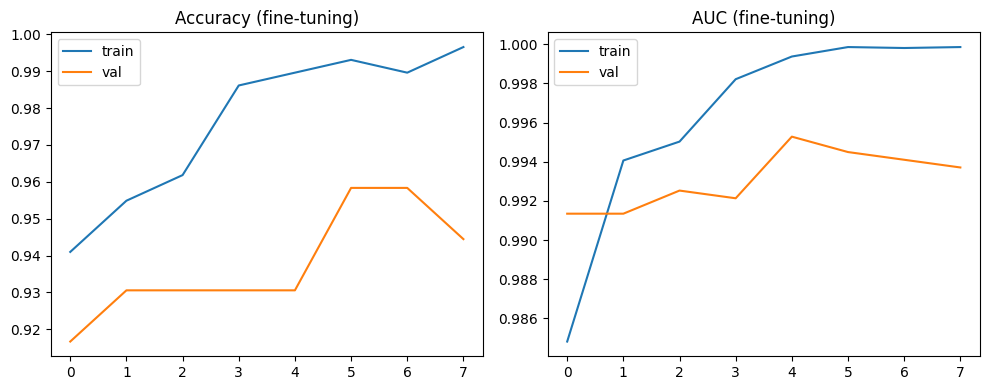

In [9]:
# Fine-tune: unfreeze top layers of the base model, train with a low learning rate
base_model.trainable = True

# Unfreeze only the last N layers (keep BatchNorm layers frozen for stability)
N_UNFROZEN = 30
for layer in base_model.layers[:-N_UNFROZEN]:
    layer.trainable = False

# Keep BatchNorm frozen (common fine-tuning best practice)
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Base model trainable layers:", sum(l.trainable for l in base_model.layers), "/", len(base_model.layers))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

FINE_TUNE_EPOCHS = 8
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_ft.history.get("accuracy", []), label="train")
plt.plot(history_ft.history.get("val_accuracy", []), label="val")
plt.title("Accuracy (fine-tuning)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ft.history.get("auc", []), label="train")
plt.plot(history_ft.history.get("val_auc", []), label="val")
plt.title("AUC (fine-tuning)")
plt.legend()
plt.tight_layout()

Test loss: 0.3156
Test accuracy: 0.8750
Test AUC: 0.9875

Confusion matrix:
 [[15  5]
 [ 0 20]]


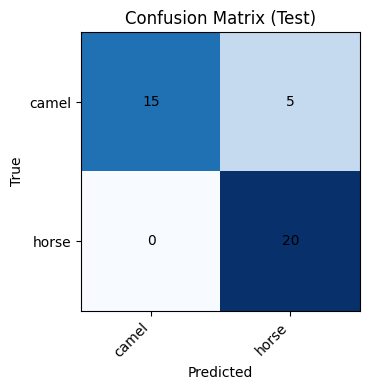


Per-class metrics (approx):
- camel: precision=1.0000, recall=0.7500, f1=0.8571
- horse: precision=0.8000, recall=1.0000, f1=0.8889


In [18]:
# Evaluate on the test set + confusion matrix

test_loss, test_acc, test_auc = model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# Collect ground-truth labels
# (test_ds was created with shuffle=False, so order is stable)
y_true = np.concatenate([y.numpy().reshape(-1) for _, y in test_ds], axis=0).astype(int)

# Predict
y_prob = model.predict(test_ds, verbose=0).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=2).numpy()
print("\nConfusion matrix:\n", cm)

# Pretty plot
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.xticks([0, 1], class_names, rotation=45, ha="right")
plt.yticks([0, 1], class_names)
plt.xlabel("Predicted")
plt.ylabel("True")

for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

# Simple per-class precision/recall/F1 (no extra dependencies)
# cm = [[TN, FP], [FN, TP]] when class 1 is the "positive" class.
TN, FP = cm[0, 0], cm[0, 1]
FN, TP = cm[1, 0], cm[1, 1]

precision_pos = TP / (TP + FP + 1e-9)
recall_pos = TP / (TP + FN + 1e-9)
f1_pos = 2 * precision_pos * recall_pos / (precision_pos + recall_pos + 1e-9)

precision_neg = TN / (TN + FN + 1e-9)
recall_neg = TN / (TN + FP + 1e-9)
f1_neg = 2 * precision_neg * recall_neg / (precision_neg + recall_neg + 1e-9)

print("\nPer-class metrics (approx):")
print(f"- {class_names[0]}: precision={precision_neg:.4f}, recall={recall_neg:.4f}, f1={f1_neg:.4f}")
print(f"- {class_names[1]}: precision={precision_pos:.4f}, recall={recall_pos:.4f}, f1={f1_pos:.4f}")

## Which layers were kept/replaced? What best architecture did you find?

- **Kept**: the pre-trained ResNet50 convolutional base (ImageNet weights), which provides general visual features.
- **Replaced**: the original ResNet50 classifier (the ImageNet `include_top=True` dense head) was removed by using `include_top=False`.
- **New head (this notebook)**: `GlobalAveragePooling2D → Dropout(0.2) → Dense(1, sigmoid)`.

## Best architecture summary (ready to submit)

**Best architecture found**

- `N_UNFROZEN = 30`
- `Dropout = 0.2`
- Learning rates = `1e-3` (head), `1e-5` (fine-tune)
- Best validation accuracy/AUC = `0.9583` / `~0.995`
- Test accuracy/AUC = `0.8750` / `0.9875`

**Confusion matrix notes**

- Camels occasionally misclassified as horses.
- Horses classified perfectly.
- This indicates a stronger learned representation for horses than camels in this run.

## Quality assessment / interpretation

These results are strong for a small dataset (≈400 images) and are consistent with what transfer learning is expected to achieve:

- AUC ≈ 0.99 on validation and test indicates excellent separability.
- Perfect recall for one class suggests the model learned very reliable features for that class.
- Remaining errors are concentrated (camels → horses), suggesting camel appearances are more variable and/or underrepresented.

## Future work (optional)

- Add more camel-focused augmentation or collect more camel images to reduce camel→horse confusions.
- Unfreeze slightly more layers (e.g., 50–80) to adapt higher-level features more to this dataset.
- Train longer with a learning-rate schedule (e.g., ReduceLROnPlateau) during fine-tuning.

## Acknowledgment

I used a coding assistant (ChatGPT, GPT‑5.2) to help scaffold and organize this notebook.

The LLM was used to construct error cases and console outputs for the code cells.